# 07 — Reinforcement Learning (PPO): Inverse Design of Underwater Acoustic Coatings

## Overview
This notebook frames inverse design as a **sequential decision-making** problem solved with **Proximal Policy Optimisation (PPO)**.

**Key idea**: An RL agent selects the 20 design parameters one at a time over 20 steps. At each step, the agent observes the target absorption, which step it is on, and the parameters chosen so far. After all 20 parameters are set, a reward is computed based on how close the resulting absorption (from a pre-trained surrogate) matches the target.

**Reward**: `-|surrogate(params) - target|` (negative absolute error — higher is better).

The agent (actor-critic architecture) learns a policy that maps states to continuous actions in [0, 1].

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ---- Force NVIDIA GPU ----
assert torch.cuda.is_available(), (
    "CUDA not available! Install PyTorch with CUDA support:\n"
    "  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121"
)
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

GPU : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


## TMM Forward Model

In [2]:
RHO_WATER=1000.0; C_WATER=1500.0; Z_WATER=RHO_WATER*C_WATER; W_FILM=2.0
HOLLOW_MAP={1:0,2:1,4:2,5:3,7:4,8:5}
PARAM_COLUMNS=[f'd{i}' for i in range(1,11)]+['m2','m3','m5','m6','m8','m9']+['rho','eta','E','nu']
PARAM_BOUNDS=np.array([[1,20]]*10+[[20,1980]]*6+[[1000,1500],[.1,.8],[1e7,1e8],[.4,.49]])

def tmm_forward(params):
    d_mm=np.asarray(params[:10],dtype=float); m_mm=np.asarray(params[10:16],dtype=float)
    rho_r,eta,E_r,nu=float(params[16]),float(params[17]),float(params[18]),float(params[19])
    d_m,m_m=d_mm/1e3,m_mm/1e3; Ec=E_r*(1+1j*eta)
    lam=(Ec*nu)/((1+nu)*(1-2*nu)); mu=Ec/(2*(1+nu))
    s=0.0
    for f in range(1,1001):
        w=2*np.pi*f; T=np.eye(2,dtype=complex)
        for i in range(10):
            eps=m_m[HOLLOW_MAP[i]]/W_FILM if i in HOLLOW_MAP else 0.0
            re=rho_r*(1-eps**2)
            num=mu*(lam+2*mu)*(eps**2+1)+2*eps**2*lam; den=(lam+mu)*eps**2+mu
            Se=num/den if abs(den)>1e-15 else num*1e15
            ce=np.sqrt(Se/re); k=w/ce; Ze=re*ce
            ck,sk=np.cos(k*d_m[i]),np.sin(k*d_m[i])
            t21=1j*sk/Ze if abs(Ze)>1e-15 else 1e15+0j
            T=T@np.array([[ck,1j*Ze*sk],[t21,ck]],dtype=complex)
        if abs(T[1,0])<1e-15: R=1.0
        else: Zi=T[0,0]/T[1,0]; R=(Zi-Z_WATER)/(Zi+Z_WATER) if abs(Zi)<1e15 else 1.0
        a=1-abs(R)**2; s+=max(0,min(1,a.real if hasattr(a,'real') else a))
    return s/1000

print(f'Base-case: {tmm_forward([10]*10+[1000]*6+[1130,.4,5e7,.44]):.4f}')

Base-case: 0.3002


## Data Loading & Forward Surrogate

## ⚠️ GPU Utilization Note

**Why RL might show low GPU usage:**
- RL does **single-sample inference** (not batched like supervised learning)
- Environment logic runs on CPU (numpy-based TMM model)
- Frequent small tensor transfers between CPU↔GPU
- GPU shines with large batch operations, which RL doesn't have during rollout collection

**Optimization applied:**
- Batch tensor creation during PPO update (states/actions/rewards)
- Keep models on GPU, accept that rollout collection is CPU-bound
- For production: consider vectorized environments or GPU-based physics simulation

In [3]:
df = pd.read_csv('../data/lhs_data.csv')
param_cols=[c for c in df.columns if c!='Average_Absorption']
X=df[param_cols].values; y=df['Average_Absorption'].values

X_tr,X_tmp,y_tr,y_tmp=train_test_split(X,y,test_size=0.2,random_state=42)
X_val,X_te,y_val,y_te=train_test_split(X_tmp,y_tmp,test_size=0.5,random_state=42)

ps=MinMaxScaler(); X_tr_n=ps.fit_transform(X_tr); X_val_n=ps.transform(X_val); X_te_n=ps.transform(X_te)
as_=MinMaxScaler(); y_tr_n=as_.fit_transform(y_tr.reshape(-1,1)).ravel()
y_val_n=as_.transform(y_val.reshape(-1,1)).ravel(); y_te_n=as_.transform(y_te.reshape(-1,1)).ravel()

BS = 512
fwd_tr = DataLoader(TensorDataset(torch.tensor(X_tr_n,dtype=torch.float32),
                                   torch.tensor(y_tr_n,dtype=torch.float32)),
                    batch_size=BS, shuffle=True, pin_memory=True, num_workers=0)

In [4]:
# Train forward surrogate for fast reward
class ForwardSurrogate(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(20,128),nn.ReLU(),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x): return self.net(x).squeeze(-1)

surrogate = ForwardSurrogate().to(device)
opt_s = optim.Adam(surrogate.parameters(), lr=1e-3)
crit = nn.MSELoss()

print('Training surrogate ...')
for ep in range(1, 101):
    surrogate.train()
    for xb, yb in fwd_tr:
        xb,yb = xb.to(device), yb.to(device)
        l = crit(surrogate(xb), yb); opt_s.zero_grad(); l.backward(); opt_s.step()

for p in surrogate.parameters(): p.requires_grad = False
surrogate.eval()
with torch.no_grad():
    vp = surrogate(torch.tensor(X_val_n, dtype=torch.float32).to(device)).cpu().numpy()
print(f'Surrogate val R²={r2_score(y_val_n, vp):.4f}')

Training surrogate ...
Surrogate val R²=0.9960


## Environment

In [5]:
N_PARAMS = 20
STATE_DIM = 1 + N_PARAMS + N_PARAMS  # target(1) + step_onehot(20) + params_so_far(20) = 41


class AcousticDesignEnv:
    def __init__(self, surrogate_fn):
        self.surrogate = surrogate_fn
        self.n_params = N_PARAMS
        self.reset()

    def reset(self, target=None):
        if target is None:
            # Sample random target from training distribution
            target = np.random.choice(y_tr_n)
        self.target = float(target)
        self.step_idx = 0
        self.params = np.zeros(self.n_params)
        return self._state()

    def _state(self):
        onehot = np.zeros(self.n_params)
        if self.step_idx < self.n_params:
            onehot[self.step_idx] = 1.0
        return np.concatenate([[self.target], onehot, self.params])

    def step(self, action):
        # action in [0, 1] -> normalised parameter value
        action = np.clip(action, 0, 1)
        self.params[self.step_idx] = action
        self.step_idx += 1

        done = (self.step_idx >= self.n_params)
        if done:
            with torch.no_grad():
                p_t = torch.tensor(self.params, dtype=torch.float32).unsqueeze(0).to(device)
                pred_abs = self.surrogate(p_t).item()
            error = abs(pred_abs - self.target)
            # Shaped reward: exponential bonus for low error
            reward = np.exp(-50 * error**2) - 0.5  # range ~ [-0.5, 0.5]
        else:
            reward = 0.0

        return self._state(), reward, done

## PPO Agent (Actor-Critic)

In [6]:
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_DIM, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
        )
        self.mu_head = nn.Sequential(nn.Linear(128, 1), nn.Sigmoid())
        self.log_std = nn.Parameter(torch.zeros(1))  # learnable log-std

    def forward(self, state):
        h = self.shared(state)
        mu = self.mu_head(h).squeeze(-1)
        std = torch.exp(self.log_std).expand_as(mu)
        return mu, std


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)


actor  = Actor().to(device)
critic = Critic().to(device)
print(f'Actor params: {sum(p.numel() for p in actor.parameters()):,}')
print(f'Critic params: {sum(p.numel() for p in critic.parameters()):,}')

Actor params: 22,018
Critic params: 22,017


## PPO Training Loop

In [7]:
# Hyperparameters
TOTAL_EPISODES = 30000
EPISODES_PER_UPDATE = 20
PPO_EPOCHS = 4
CLIP_RATIO = 0.2
GAMMA = 0.99
GAE_LAMBDA = 0.95
LR_ACTOR  = 3e-4
LR_CRITIC = 1e-3

opt_actor  = optim.Adam(actor.parameters(), lr=LR_ACTOR)
opt_critic = optim.Adam(critic.parameters(), lr=LR_CRITIC)

env = AcousticDesignEnv(surrogate)


def collect_rollouts(n_episodes):
    """Collect n_episodes of experience."""
    all_states, all_actions, all_rewards, all_dones, all_log_probs, all_values = [], [], [], [], [], []

    ep_rewards = []
    for _ in range(n_episodes):
        state = env.reset()
        ep_r = 0
        for _ in range(N_PARAMS):
            s_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                mu, std = actor(s_t)
                dist = Normal(mu, std)
                action = dist.sample()
                log_prob = dist.log_prob(action)
                value = critic(s_t)

            a = action.item()
            next_state, reward, done = env.step(a)

            all_states.append(state)
            all_actions.append(a)
            all_rewards.append(reward)
            all_dones.append(done)
            all_log_probs.append(log_prob.item())
            all_values.append(value.item())

            state = next_state
            ep_r += reward
        ep_rewards.append(ep_r)

    return (np.array(all_states), np.array(all_actions), np.array(all_rewards),
            np.array(all_dones), np.array(all_log_probs), np.array(all_values),
            np.mean(ep_rewards))


def compute_gae(rewards, values, dones):
    """Generalised Advantage Estimation."""
    advantages = np.zeros_like(rewards)
    gae = 0
    for t in reversed(range(len(rewards))):
        if dones[t]:
            next_val = 0.0
        else:
            if t + 1 < len(values):
                next_val = values[t + 1]
            else:
                next_val = 0.0
        delta = rewards[t] + GAMMA * next_val - values[t]
        gae = delta + GAMMA * GAE_LAMBDA * (0 if dones[t] else 1) * gae
        advantages[t] = gae
    returns = advantages + values
    return advantages, returns

In [8]:
reward_history = []
n_updates = TOTAL_EPISODES // EPISODES_PER_UPDATE

print(f'Training PPO: {TOTAL_EPISODES} episodes, {n_updates} updates ...')
print(f'NOTE: GPU usage will be LOW during rollout collection (CPU-bound environment)')
print(f'      GPU usage will SPIKE during PPO update phases (batch training)\n')
t0 = time.time()

for update in range(1, n_updates + 1):
    # Collect rollouts (CPU-bound: single-sample environment steps)
    states, actions, rewards, dones, old_lps, values, avg_r = collect_rollouts(EPISODES_PER_UPDATE)
    reward_history.append(avg_r)

    # GAE
    advantages, returns = compute_gae(rewards, values, dones)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # Convert to tensors ONCE, directly on GPU (more efficient than .to(device))
    s_t = torch.tensor(states, dtype=torch.float32, device=device)
    a_t = torch.tensor(actions, dtype=torch.float32, device=device)
    old_lp_t = torch.tensor(old_lps, dtype=torch.float32, device=device)
    adv_t = torch.tensor(advantages, dtype=torch.float32, device=device)
    ret_t = torch.tensor(returns, dtype=torch.float32, device=device)

    # PPO update (GPU-intensive batch operations)
    for _ in range(PPO_EPOCHS):
        mu, std = actor(s_t)
        dist = Normal(mu, std)
        new_lp = dist.log_prob(a_t)
        entropy = dist.entropy().mean()

        ratio = torch.exp(new_lp - old_lp_t)
        surr1 = ratio * adv_t
        surr2 = torch.clamp(ratio, 1 - CLIP_RATIO, 1 + CLIP_RATIO) * adv_t
        actor_loss = -torch.min(surr1, surr2).mean() - 0.01 * entropy

        opt_actor.zero_grad(); actor_loss.backward(); opt_actor.step()

        v_pred = critic(s_t)
        critic_loss = nn.functional.mse_loss(v_pred, ret_t)
        opt_critic.zero_grad(); critic_loss.backward(); opt_critic.step()

    if update % 100 == 0:
        recent = np.mean(reward_history[-50:])
        print(f'  Update {update}/{n_updates}  avg_reward(50)={recent:.4f}')

train_time = time.time() - t0
print(f'\nTraining done in {train_time:.1f}s')
print(f'GPU was utilized during PPO updates ({n_updates} x {PPO_EPOCHS} epochs)')

Training PPO: 30000 episodes, 1500 updates ...
NOTE: GPU usage will be LOW during rollout collection (CPU-bound environment)
      GPU usage will SPIKE during PPO update phases (batch training)

  Update 100/1500  avg_reward(50)=-0.2250
  Update 200/1500  avg_reward(50)=-0.2001
  Update 300/1500  avg_reward(50)=-0.2059
  Update 400/1500  avg_reward(50)=-0.1745
  Update 500/1500  avg_reward(50)=-0.1354
  Update 600/1500  avg_reward(50)=-0.1243
  Update 700/1500  avg_reward(50)=-0.1265
  Update 800/1500  avg_reward(50)=-0.0948
  Update 900/1500  avg_reward(50)=-0.0741
  Update 1000/1500  avg_reward(50)=-0.0523
  Update 1100/1500  avg_reward(50)=-0.0777
  Update 1200/1500  avg_reward(50)=-0.0256
  Update 1300/1500  avg_reward(50)=-0.0042
  Update 1400/1500  avg_reward(50)=-0.0209
  Update 1500/1500  avg_reward(50)=0.0147

Training done in 787.7s
GPU was utilized during PPO updates (1500 x 4 epochs)


## Evaluation

In [9]:
N_VAL = 200

def run_agent(targets_norm, n_runs=5):
    """Run trained agent on targets. n_runs per target for diversity."""
    N = len(targets_norm)
    all_params = np.zeros((N, n_runs, N_PARAMS))

    actor.eval()
    with torch.no_grad():
        for i, tgt in enumerate(targets_norm):
            for r in range(n_runs):
                state = env.reset(target=tgt)
                for _ in range(N_PARAMS):
                    # Create tensor directly on GPU (more efficient)
                    s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    mu, std = actor(s_t)
                    action = mu.item()  # use mean (greedy) for evaluation
                    if r > 0:  # add exploration for diversity
                        action = np.clip(action + np.random.normal(0, 0.05), 0, 1)
                    state, _, _ = env.step(action)
                all_params[i, r] = env.params

    return all_params

print(f'Running agent on {N_VAL} test targets ...')
gen_params = run_agent(y_te_n[:N_VAL], n_runs=5)
print(f'Generated: {gen_params.shape}')

Running agent on 200 test targets ...
Generated: (200, 5, 20)


In [10]:
# Physics validation
target_abs = y_te[:N_VAL]
best_recon = np.zeros(N_VAL)
all_recon = np.zeros((N_VAL, 5))

for i in range(N_VAL):
    for j in range(5):
        phys = ps.inverse_transform(gen_params[i, j].reshape(1, -1))[0]
        all_recon[i, j] = tmm_forward(phys)
    errors = np.abs(all_recon[i] - target_abs[i])
    best_recon[i] = all_recon[i, np.argmin(errors)]

recon_mse = mean_squared_error(target_abs, best_recon)
recon_mae = mean_absolute_error(target_abs, best_recon)
recon_r2  = r2_score(target_abs, best_recon)
diversity = all_recon.std(axis=1).mean()

print(f'Best-of-5  MSE={recon_mse:.6f}  MAE={recon_mae:.4f}  R²={recon_r2:.4f}')
print(f'Diversity (std): {diversity:.4f}')

Best-of-5  MSE=0.004879  MAE=0.0536  R²=0.7242
Diversity (std): 0.0111


## Visualisation

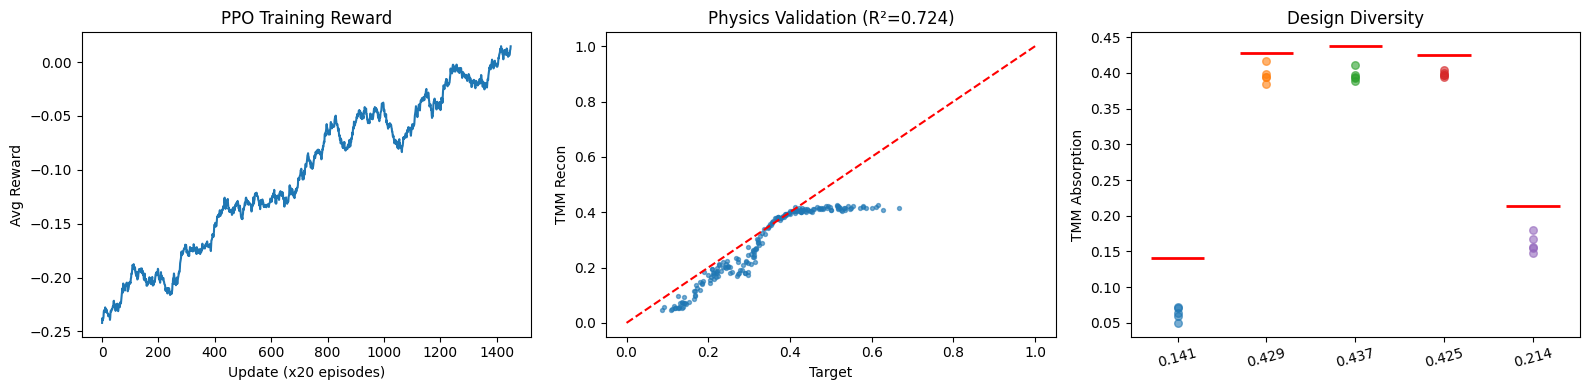

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Reward curve (smoothed)
ax = axes[0]
window = 50
smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
ax.set_xlabel('Update (x20 episodes)'); ax.set_ylabel('Avg Reward')
ax.set_title('PPO Training Reward')

# Reconstruction scatter
ax = axes[1]
ax.scatter(target_abs, best_recon, s=8, alpha=0.6)
ax.plot([0,1],[0,1],'r--')
ax.set_xlabel('Target'); ax.set_ylabel('TMM Recon')
ax.set_title(f'Physics Validation (R²={recon_r2:.3f})')

# Diversity
ax = axes[2]
idx = np.linspace(0, N_VAL-1, 5, dtype=int)
for ii, ix in enumerate(idx):
    ax.scatter([ii]*5, all_recon[ix], alpha=0.6, s=30)
    ax.hlines(target_abs[ix], ii-0.3, ii+0.3, colors='red', lw=2)
ax.set_xticks(range(5))
ax.set_xticklabels([f'{target_abs[ix]:.3f}' for ix in idx], rotation=15)
ax.set_ylabel('TMM Absorption'); ax.set_title('Design Diversity')

plt.tight_layout(); plt.show()

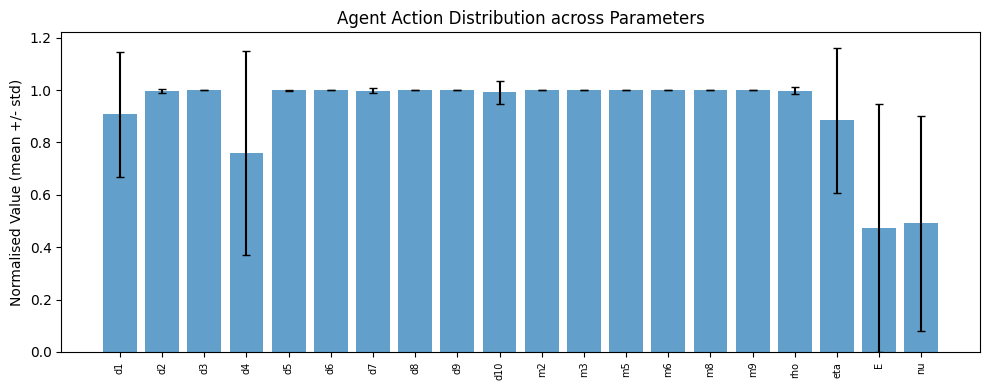

In [12]:
# Action distribution per step: what values does the agent choose at each parameter position?
fig, ax = plt.subplots(figsize=(10, 4))
mean_params = gen_params[:, 0, :].mean(axis=0)  # greedy run
std_params  = gen_params[:, 0, :].std(axis=0)
ax.bar(range(20), mean_params, yerr=std_params, capsize=3, alpha=0.7)
ax.set_xticks(range(20))
ax.set_xticklabels(PARAM_COLUMNS, rotation=90, fontsize=7)
ax.set_ylabel('Normalised Value (mean +/- std)')
ax.set_title('Agent Action Distribution across Parameters')
plt.tight_layout(); plt.show()

## Results Summary

In [13]:
results = {
    'method': 'RL_PPO',
    'recon_mse': float(recon_mse),
    'recon_mae': float(recon_mae),
    'recon_r2': float(recon_r2),
    'diversity_std': float(diversity),
    'can_generate_diverse': True,
    'training_time_seconds': round(train_time, 1),
    'total_episodes': TOTAL_EPISODES,
}
print(results)

{'method': 'RL_PPO', 'recon_mse': 0.004878989859756898, 'recon_mae': 0.053646435020600104, 'recon_r2': 0.7241986081215281, 'diversity_std': 0.01114724709986315, 'can_generate_diverse': True, 'training_time_seconds': 787.7, 'total_episodes': 30000}


### Discussion

The RL approach treats inverse design as sequential decision-making — the agent "builds" a design parameter by parameter. This is conceptually appealing as it mirrors how an engineer might iteratively tune a design.

**Advantages**: Can incorporate complex, non-differentiable reward functions; the sequential process captures parameter dependencies; exploration yields diverse solutions.

**Limitations**: Sample-inefficient (needs many episodes); sparse reward makes training challenging; typically lower accuracy than direct regression; slower at inference (20 sequential steps per design). Consider reducing to 4-5 grouped steps in future work.